A test implementation based off of the method described in https://ismir2005.ismir.net/proceedings/1053.pdf

In [33]:
import librosa
import numpy as np 
import matplotlib.pyplot as plt
import librosa.display


filename = 'test_file.mp3'

y, sr = librosa.load(filename)

center_y = len(y)//2
minute_y = librosa.time_to_samples(60, sr=sr)

start = max(0,center_y-minute_y)
end = min(len(y), center_y + minute_y)

segment = y[start:end]
#they use 512 samples 
#50% overlap would be a hop of 256 
#since magnitude use np.abs
#compute the short time fourier transform 

S = np.abs(librosa.stft(segment, n_fft=512, hop_length=256))
S_power = S**2
S_power_centered = S_power - np.mean(S_power,axis=0,keepdims=True)
S_power_centered = np.maximum(S_power_centered, 0)
mel = librosa.feature.melspectrogram(S=S_power_centered,sr=sr, n_mels=40)
mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=20)


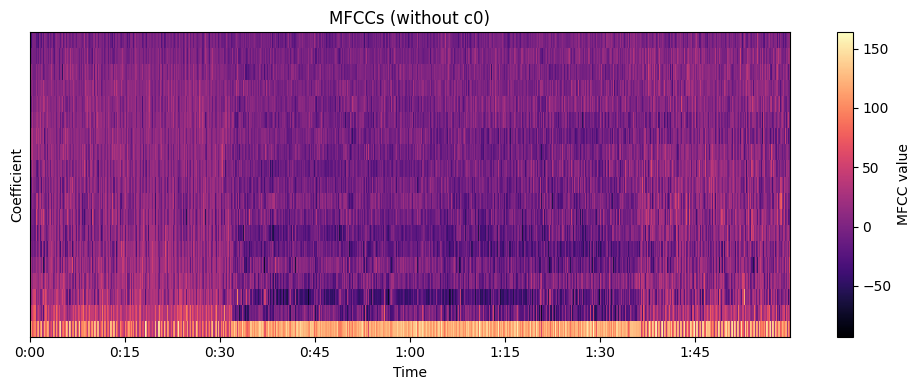

In [29]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc[1:],           # remove energy coefficient
    sr=sr,
    hop_length=256,
    x_axis="time",
    cmap="magma"
)

plt.colorbar(label="MFCC value")
plt.title("MFCCs (without c0)")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()



Fluctuation Partterns 

In [36]:
import librosa
import numpy as np

def compute_fluctuation_pattern(
    filename,
    sr=22050,
    n_mels=20,
    n_fft=2048,
    hop_length=512,
    fmin=20,
    fmax=16000,
    mod_max_hz=10.0,
    n_mod_bins=60,
):
    """
    Compute an approximate 20 x 60 fluctuation pattern (FP).

    Rows   : perceptual frequency bands
    Columns: modulation frequencies from 0 to 10 Hz
    Values : fluctuation strength
    """
    y, sr = librosa.load(filename)

    # 1) band-wise loudness over time
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
        power=2,
    )

    # Convert to dB so each band is closer to perceived loudness
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2) modulation spectrum of each band (FFT across time axis)
    mod_spec = np.abs(np.fft.rfft(mel_db, axis=1))

    # Envelope sampling rate: how often each band-loudness value is sampled
    env_sr = sr / hop_length
    mod_freqs = np.fft.rfftfreq(mel_db.shape[1], d=1 / env_sr)

    # 3) keep only modulation frequencies in [0, 10] Hz
    mask = (mod_freqs >= 0) & (mod_freqs <= mod_max_hz)
    mod_freqs_kept = mod_freqs[mask]
    fp_raw = mod_spec[:, mask]

    # 4) resample modulation axis to exactly 60 bins
    target_mod_freqs = np.linspace(0, mod_max_hz, n_mod_bins)
    fp = np.zeros((n_mels, n_mod_bins), dtype=np.float64)

    for i in range(n_mels):
        fp[i] = np.interp(target_mod_freqs, mod_freqs_kept, fp_raw[i])

    return fp, target_mod_freqs


def fp_focus(fp):
    """
    Focus as described in the text:
    normalize FP so max = 1, then take mean of all entries.

    Lower value  -> energy concentrated in small regions
    Higher value -> energy spread out more broadly
    """
    fp_norm = fp / (np.max(fp) + 1e-12)
    return np.mean(fp_norm)


def fp_gravity(fp):
    """
    Gravity as described in the text:
    compute center of gravity along the modulation-frequency axis,
    then subtract the theoretical mean (~31st bin).

    Uses bin indices 1..60, matching the paper description.
    """
    col_energy = np.sum(fp, axis=0)          # shape (60,)
    bins = np.arange(1, fp.shape[1] + 1)     # 1..60

    center = np.sum(bins * col_energy) / (np.sum(col_energy) + 1e-12)
    gravity = center - 31.0
    return gravity


def fp_vector(fp):
    """Flatten FP to a 1200-dimensional vector."""
    return fp.flatten()


def fp_distance(fp1, fp2):
    """Euclidean distance between two fluctuation patterns."""
    return np.linalg.norm(fp_vector(fp1) - fp_vector(fp2))


def focus_distance(fp1, fp2):
    """Absolute difference between Focus values."""
    return abs(fp_focus(fp1) - fp_focus(fp2))


def gravity_distance(fp1, fp2):
    """Absolute difference between Gravity values."""
    return abs(fp_gravity(fp1) - fp_gravity(fp2))


# -------------------------
# Example usage: one song
# -------------------------
file1 = "test_file.mp3"

fp1, mod_freqs1 = compute_fluctuation_pattern(file1)

focus1 = fp_focus(fp1)
gravity1 = fp_gravity(fp1)
vec1 = fp_vector(fp1)

print("FP shape:", fp1.shape)          # should be (20, 60)
print("Focus:", focus1)
print("Gravity:", gravity1)
print("Vector length:", len(vec1))     # should be 1200


# -------------------------
# Example usage: two songs
# -------------------------
file2 = "test_file_2.mp3"

fp2, mod_freqs2 = compute_fluctuation_pattern(file2)

print("FP Euclidean distance:", fp_distance(fp1, fp2))
print("Focus distance:", focus_distance(fp1, fp2))
print("Gravity distance:", gravity_distance(fp1, fp2))



c:\Users\james\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


FP shape: (20, 60)
Focus: 0.008105534955368
Gravity: -28.724532497766216
Vector length: 1200
FP Euclidean distance: 495358.9232723106
Focus distance: 0.0025477954027991693
Gravity distance: 0.4435759194240241
